<a href="https://colab.research.google.com/github/syednuaymnadeem/Grad-CAM-Implementation/blob/main/Grad_CAM_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models


# -----------------------------
# Repro + Config
# -----------------------------
@dataclass
class CFG:
    data_dir: str = "./data"
    out_dir: str = "./outputs_ms2"

    batch_size: int = 64
    lr: float = 0.01
    epochs: int = 5
    seed: int = 42

    # bias / cue
    bias_class_idx: int = 6  # frog
    patch_size: int = 6
    patch_color_bgr: Tuple[int, int, int] = (0, 255, 255)  # yellow in BGR for OpenCV (but we write into numpy directly)
    swapped_prob: float = 1.0  # for swapped test: probability to add patch to non-frog images (1.0 = strongest)

    # evaluation
    cfs_samples: int = 200
    save_cam_examples: int = 6  # save this many examples per condition
    show_plots_inline: bool = False  # set True if you want plt.show() in notebook


cfg = CFG()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {DEVICE}")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


# -----------------------------
# Dataset with modes
# -----------------------------
class CueCIFAR10(torchvision.datasets.CIFAR10):
    """
    Modes:
      - "clean": no patch anywhere
      - "train_biased": add patch ONLY to bias class (frogs) (training distribution)
      - "test_present": frogs have patch (same as biased training for frogs)
      - "test_removed": frogs do NOT have patch
      - "test_swapped": frogs do NOT have patch; non-frogs get patch with prob=swapped_prob
    """

    def __init__(
        self,
        *args,
        mode: str,
        bias_class_idx: int,
        patch_size: int,
        patch_color_rgb: Tuple[int, int, int] = (255, 255, 0),  # yellow RGB
        swapped_prob: float = 1.0,
        **kwargs
    ):
        self.user_transform = kwargs.get("transform", None)
        kwargs["transform"] = None
        super().__init__(*args, **kwargs)

        self.mode = mode
        self.bias_class_idx = bias_class_idx
        self.patch_size = patch_size
        self.patch_color_rgb = patch_color_rgb
        self.swapped_prob = swapped_prob

    def _apply_patch(self, img_np: np.ndarray):
        # img_np is HxWx3 uint8
        ps = self.patch_size
        img_np[0:ps, 0:ps] = np.array(self.patch_color_rgb, dtype=np.uint8)

    def __getitem__(self, index):
        img = self.data[index]          # uint8 HxWx3
        target = self.targets[index]    # int label
        img = img.copy()

        if self.mode == "clean":
            pass

        elif self.mode == "train_biased":
            # patch only on frogs
            if target == self.bias_class_idx:
                self._apply_patch(img)

        elif self.mode == "test_present":
            # frogs patched (in-distribution for biased model)
            if target == self.bias_class_idx:
                self._apply_patch(img)

        elif self.mode == "test_removed":
            # frogs NOT patched (OOD)
            pass

        elif self.mode == "test_swapped":
            # frogs NOT patched; non-frogs get patch w/ prob swapped_prob (conflicting cue)
            if target != self.bias_class_idx and random.random() < self.swapped_prob:
                self._apply_patch(img)

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

        img = torchvision.transforms.ToPILImage()(img)

        if self.user_transform is not None:
            img = self.user_transform(img)

        return img, target


# -----------------------------
# Dataloaders
# -----------------------------
def get_transforms():
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    return transform_train, transform_test


def get_trainloader(biased: bool):
    t_train, _ = get_transforms()
    if biased:
        print("Loading BIASED TRAIN set (frogs have yellow patch)...")
        trainset = CueCIFAR10(
            root=cfg.data_dir, train=True, download=True,
            transform=t_train,
            mode="train_biased",
            bias_class_idx=cfg.bias_class_idx,
            patch_size=cfg.patch_size,
            patch_color_rgb=(255, 255, 0)
        )
    else:
        print("Loading CLEAN TRAIN set (no patches)...")
        trainset = torchvision.datasets.CIFAR10(
            root=cfg.data_dir, train=True, download=True, transform=t_train
        )

    return torch.utils.data.DataLoader(
        trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True
    )


def get_testloader(mode: str):
    _, t_test = get_transforms()
    print(f"Loading TEST set mode={mode} ...")
    testset = CueCIFAR10(
        root=cfg.data_dir, train=False, download=True,
        transform=t_test,
        mode=mode,
        bias_class_idx=cfg.bias_class_idx,
        patch_size=cfg.patch_size,
        patch_color_rgb=(255, 255, 0),
        swapped_prob=cfg.swapped_prob
    )

    return torch.utils.data.DataLoader(
        testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True
    )


CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# -----------------------------
# Model (ResNet18 modified for CIFAR-10)
# -----------------------------
def get_resnet_cifar():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)


# -----------------------------
# Grad-CAM implementation (no external library)
# -----------------------------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image: torch.Tensor, target_class: Optional[int] = None):
        """
        input_image: shape [1,3,32,32]
        target_class:
          - None => use predicted class (recommended for "explain model decision")
          - int  => force a specific class (useful for failure analysis)
        returns:
          cam: 32x32 float [0,1]
          used_class: int (the class we backprop'd)
          pred_class: int (the model's predicted class)
        """
        output = self.model(input_image)
        pred_class = output.argmax(dim=1).item()

        if target_class is None:
            used_class = pred_class
        else:
            used_class = int(target_class)

        self.model.zero_grad()

        one_hot = torch.zeros_like(output)
        one_hot[0, used_class] = 1.0

        output.backward(gradient=one_hot)

        gradients = self.gradients.detach().cpu().numpy()[0]     # [C,H,W]
        activations = self.activations.detach().cpu().numpy()[0] # [C,H,W]

        weights = np.mean(gradients, axis=(1, 2))  # [C]

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (32, 32))

        if (cam.max() - cam.min()) > 1e-8:
            cam = cam - cam.min()
            cam = cam / (cam.max() + 1e-8)
        else:
            cam = np.zeros_like(cam, dtype=np.float32)

        return cam, used_class, pred_class


# -----------------------------
# Visualization + Saving
# -----------------------------
def denormalize_cifar(img_t: torch.Tensor) -> np.ndarray:
    """
    img_t: [3,32,32] normalized tensor
    returns: HxWx3 float in [0,1]
    """
    img = img_t.detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0.0, 1.0)
    return img


def overlay_cam(img01: np.ndarray, cam01: np.ndarray) -> np.ndarray:
    """
    img01: HxWx3 float [0,1]
    cam01: HxW float [0,1]
    returns: HxWx3 uint8 RGB
    """
    heatmap = cv2.applyColorMap(np.uint8(255 * cam01), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    heatmap = heatmap[..., ::-1]  # BGR->RGB

    blended = heatmap + np.float32(img01)
    blended = blended / (blended.max() + 1e-8)
    blended = np.clip(blended, 0, 1)
    return (blended * 255).astype(np.uint8)


def save_cam_figure(img_t: torch.Tensor, cam01: np.ndarray, save_path: str, title: str):
    img01 = denormalize_cifar(img_t)
    cam_img = overlay_cam(img01, cam01)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img01)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(cam_img)
    ax[1].set_title(title)
    ax[1].axis("off")

    fig.tight_layout()
    ensure_dir(os.path.dirname(save_path))
    fig.savefig(save_path, dpi=200)
    if cfg.show_plots_inline:
        plt.show()
    plt.close(fig)


# -----------------------------
# Metrics: Accuracy + CFS
# -----------------------------
@torch.no_grad()
def eval_accuracy(model: nn.Module, loader) -> float:
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total if total > 0 else 0.0


def cue_focus_score(cam01: np.ndarray, patch_size: int) -> float:
    """
    cam01 is 32x32 in [0,1]
    CFS = heat mass inside cue region / total heat mass
    """
    cam = np.maximum(cam01, 0.0)
    cue = cam[:patch_size, :patch_size].sum()
    total = cam.sum()
    return float(cue / (total + 1e-8))


def compute_mean_cfs(model: nn.Module, loader, gradcam: GradCAM, max_samples: int) -> float:
    model.eval()
    scores: List[float] = []
    seen = 0

    with torch.enable_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            for i in range(x.size(0)):
                if seen >= max_samples:
                    return float(np.mean(scores)) if scores else 0.0

                cam01, used_class, pred_class = gradcam.generate_cam(x[i].unsqueeze(0), target_class=None)
                scores.append(cue_focus_score(cam01, cfg.patch_size))
                seen += 1

    return float(np.mean(scores)) if scores else 0.0


# -----------------------------
# Train
# -----------------------------
def train_model(model: nn.Module, trainloader, epochs: int):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    print(f"Starting Training for {epochs} epochs...")
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(trainloader, 0):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0

        scheduler.step()

    print("Training Finished.")


# -----------------------------
# Experiment runner
# -----------------------------
def run_experiment(train_biased: bool, tag: str) -> Dict[str, float]:
    """
    Train one model (baseline or biased), then evaluate on:
      - clean test (no patch)
      - test_present / test_removed / test_swapped
    Saves Grad-CAM images for each condition.

    Returns a dict of accuracies + CFS for report table.
    """
    print("\n=======================================")
    print(f"TRAINING MODEL: {tag}")
    print("=======================================")

    trainloader = get_trainloader(biased=train_biased)
    model = get_resnet_cifar()
    train_model(model, trainloader, epochs=cfg.epochs)

    # Grad-CAM target layer
    target_layer = model.layer4[-1].conv2
    grad_cam = GradCAM(model, target_layer)

    # Test loaders
    test_clean = torch.utils.data.DataLoader(
        torchvision.datasets.CIFAR10(
            root=cfg.data_dir, train=False, download=True,
            transform=get_transforms()[1]
        ),
        batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    test_present = get_testloader("test_present")
    test_removed = get_testloader("test_removed")
    test_swapped = get_testloader("test_swapped")

    # Accuracy metrics
    acc_clean = eval_accuracy(model, test_clean)
    acc_present = eval_accuracy(model, test_present)
    acc_removed = eval_accuracy(model, test_removed)
    acc_swapped = eval_accuracy(model, test_swapped)

    # CFS metrics (mean over cfg.cfs_samples)
    cfs_present = compute_mean_cfs(model, test_present, grad_cam, max_samples=cfg.cfs_samples)
    cfs_removed = compute_mean_cfs(model, test_removed, grad_cam, max_samples=cfg.cfs_samples)
    cfs_swapped = compute_mean_cfs(model, test_swapped, grad_cam, max_samples=cfg.cfs_samples)

    print(f"\n[{tag}] Acc clean   : {acc_clean*100:.2f}%")
    print(f"[{tag}] Acc present : {acc_present*100:.2f}%")
    print(f"[{tag}] Acc removed  : {acc_removed*100:.2f}%")
    print(f"[{tag}] Acc swapped  : {acc_swapped*100:.2f}%")

    print(f"[{tag}] CFS present  : {cfs_present:.4f}")
    print(f"[{tag}] CFS removed   : {cfs_removed:.4f}")
    print(f"[{tag}] CFS swapped   : {cfs_swapped:.4f}")

    # Save Grad-CAM examples for report
    ensure_dir(cfg.out_dir)

    def save_some(loader, condition_name: str):
        model.eval()
        saved = 0
        with torch.enable_grad():
            for x, y in loader:
                x = x.to(DEVICE)
                y_np = y.numpy()
                for i in range(x.size(0)):
                    if saved >= cfg.save_cam_examples:
                        return
                    cam01, used_cls, pred_cls = grad_cam.generate_cam(x[i].unsqueeze(0), target_class=None)

                    true_name = CLASSES[int(y_np[i])]
                    pred_name = CLASSES[int(pred_cls)]
                    title = f"{condition_name} | true={true_name} pred={pred_name} (cam=pred)"

                    save_path = os.path.join(cfg.out_dir, f"gradcam_{tag}_{condition_name}_{saved:02d}.png")
                    save_cam_figure(x[i], cam01, save_path, title=title)
                    saved += 1

    save_some(test_present, "present")
    save_some(test_removed, "removed")
    save_some(test_swapped, "swapped")

    return {
        "acc_clean": acc_clean,
        "acc_present": acc_present,
        "acc_removed": acc_removed,
        "acc_swapped": acc_swapped,
        "cfs_present": cfs_present,
        "cfs_removed": cfs_removed,
        "cfs_swapped": cfs_swapped,
    }


def main():
    set_seed(cfg.seed)
    ensure_dir(cfg.out_dir)

    print("=======================================")
    print("STEP 1: BASELINE (CLEAN TRAIN)")
    print("=======================================")
    baseline = run_experiment(train_biased=False, tag="baseline")

    print("\n=======================================")
    print("STEP 2: BIASED (FROG PATCH TRAIN)")
    print("=======================================")
    biased = run_experiment(train_biased=True, tag="biased")

    # MS2-ready summary table lines
    print("\n==================== MS2 SUMMARY (copy into report) ====================")
    print(
        f"Baseline: Acc clean={baseline['acc_clean']*100:.2f}%, present={baseline['acc_present']*100:.2f}%, "
        f"removed={baseline['acc_removed']*100:.2f}%, swapped={baseline['acc_swapped']*100:.2f}% | "
        f"CFS present={baseline['cfs_present']:.4f}, removed={baseline['cfs_removed']:.4f}, swapped={baseline['cfs_swapped']:.4f}"
    )
    print(
        f"Biased:   Acc clean={biased['acc_clean']*100:.2f}%, present={biased['acc_present']*100:.2f}%, "
        f"removed={biased['acc_removed']*100:.2f}%, swapped={biased['acc_swapped']*100:.2f}% | "
        f"CFS present={biased['cfs_present']:.4f}, removed={biased['cfs_removed']:.4f}, swapped={biased['cfs_swapped']:.4f}"
    )
    print("Saved Grad-CAM figures to:", cfg.out_dir)
    print("=======================================================================")


if __name__ == "__main__":
    main()


Running on device: cuda
STEP 1: BASELINE (CLEAN TRAIN)

TRAINING MODEL: baseline
Loading CLEAN TRAIN set (no patches)...


100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


Starting Training for 5 epochs...
[Epoch 1, Batch 100] loss: 2.033
[Epoch 1, Batch 200] loss: 1.757
[Epoch 1, Batch 300] loss: 1.636
[Epoch 1, Batch 400] loss: 1.512
[Epoch 1, Batch 500] loss: 1.388
[Epoch 1, Batch 600] loss: 1.321
[Epoch 1, Batch 700] loss: 1.263
[Epoch 2, Batch 100] loss: 1.148
[Epoch 2, Batch 200] loss: 1.087
[Epoch 2, Batch 300] loss: 1.052
[Epoch 2, Batch 400] loss: 0.996
[Epoch 2, Batch 500] loss: 0.966
[Epoch 2, Batch 600] loss: 0.870
[Epoch 2, Batch 700] loss: 0.912
[Epoch 3, Batch 100] loss: 0.828
[Epoch 3, Batch 200] loss: 0.812
[Epoch 3, Batch 300] loss: 0.776
[Epoch 3, Batch 400] loss: 0.741
[Epoch 3, Batch 500] loss: 0.734
[Epoch 3, Batch 600] loss: 0.746
[Epoch 3, Batch 700] loss: 0.735
[Epoch 4, Batch 100] loss: 0.681
[Epoch 4, Batch 200] loss: 0.652
[Epoch 4, Batch 300] loss: 0.671
[Epoch 4, Batch 400] loss: 0.652
[Epoch 4, Batch 500] loss: 0.635
[Epoch 4, Batch 600] loss: 0.637
[Epoch 4, Batch 700] loss: 0.627
[Epoch 5, Batch 100] loss: 0.592
[Epoch 5,

In [ ]:
!git clone https://github.com/syednuaymnadeem/Grad-CAM-Implementation.git
%cd Grad-CAM-Implementation

Cloning into 'Grad-CAM-Implementation'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
/content/Grad-CAM-Implementation


In [ ]:
!ls -la /content

total 20
drwxr-xr-x 1 root root 4096 Feb 25 15:24 .
drwxr-xr-x 1 root root 4096 Feb 25 15:21 ..
drwxr-xr-x 4 root root 4096 Feb  6 14:31 .config
drwxr-xr-x 3 root root 4096 Feb 25 15:24 Grad-CAM-Implementation
drwxr-xr-x 1 root root 4096 Feb  6 14:31 sample_data


In [ ]:
!ls -lah outputs_ms2 | head -n 50


total 1.2M
drwxr-xr-x 2 root root 4.0K Feb  9 00:08 .
drwxr-xr-x 1 root root 4.0K Feb  9 00:00 ..
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_present_00.png
-rw-r--r-- 1 root root  31K Feb  9 00:04 gradcam_baseline_present_01.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_present_02.png
-rw-r--r-- 1 root root  33K Feb  9 00:04 gradcam_baseline_present_03.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_present_04.png
-rw-r--r-- 1 root root  31K Feb  9 00:04 gradcam_baseline_present_05.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_removed_00.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_removed_01.png
-rw-r--r-- 1 root root  33K Feb  9 00:04 gradcam_baseline_removed_02.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_removed_03.png
-rw-r--r-- 1 root root  33K Feb  9 00:04 gradcam_baseline_removed_04.png
-rw-r--r-- 1 root root  32K Feb  9 00:04 gradcam_baseline_removed_05.png
-rw-r--r-- 1 root root  33

Total images: 36


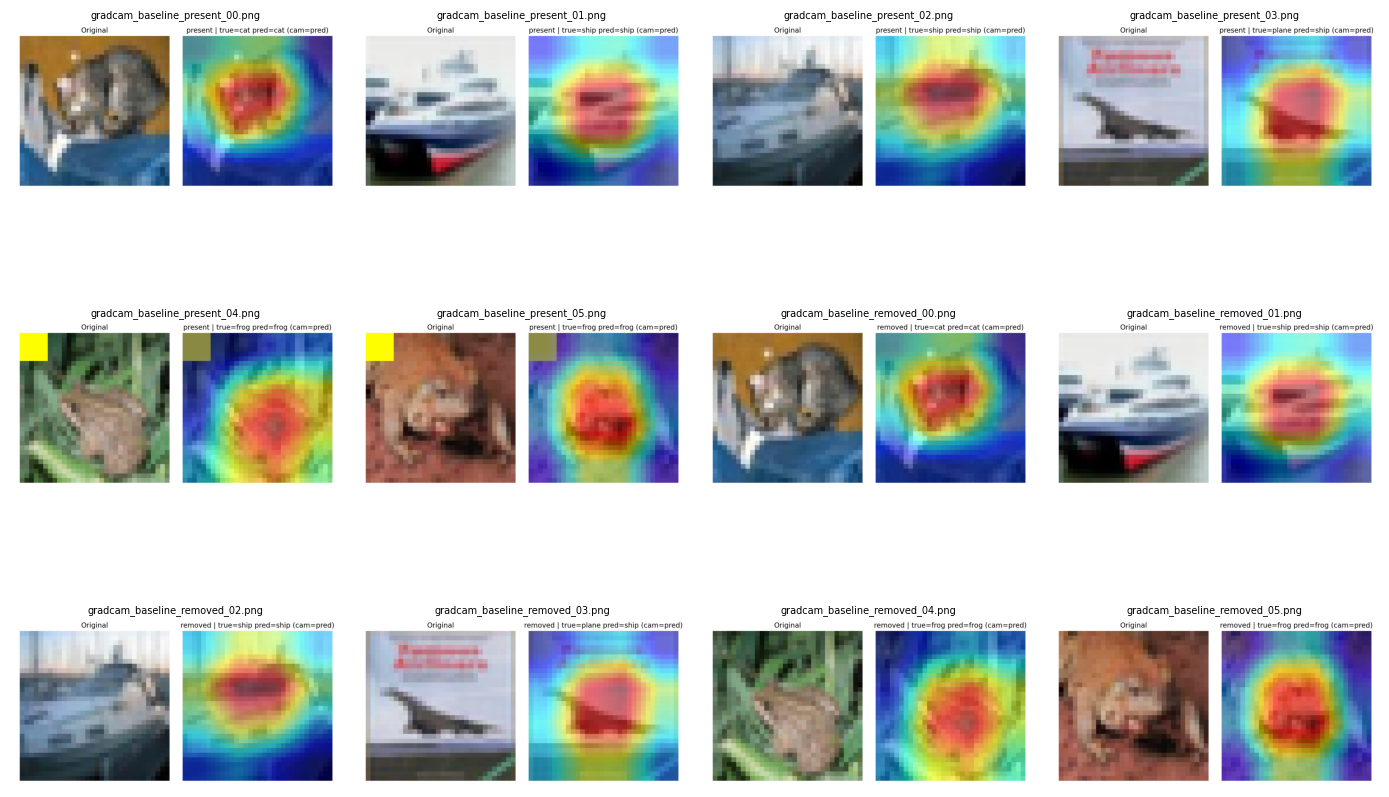

In [ ]:
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt

paths = sorted(glob("outputs_ms2/*.png"))
print("Total images:", len(paths))

# show 12 images
show = paths[:12]
plt.figure(figsize=(14, 10))
for i, p in enumerate(show):
    img = Image.open(p)
    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(p.split("/")[-1], fontsize=7)
    plt.axis("off")
plt.tight_layout()
plt.show()


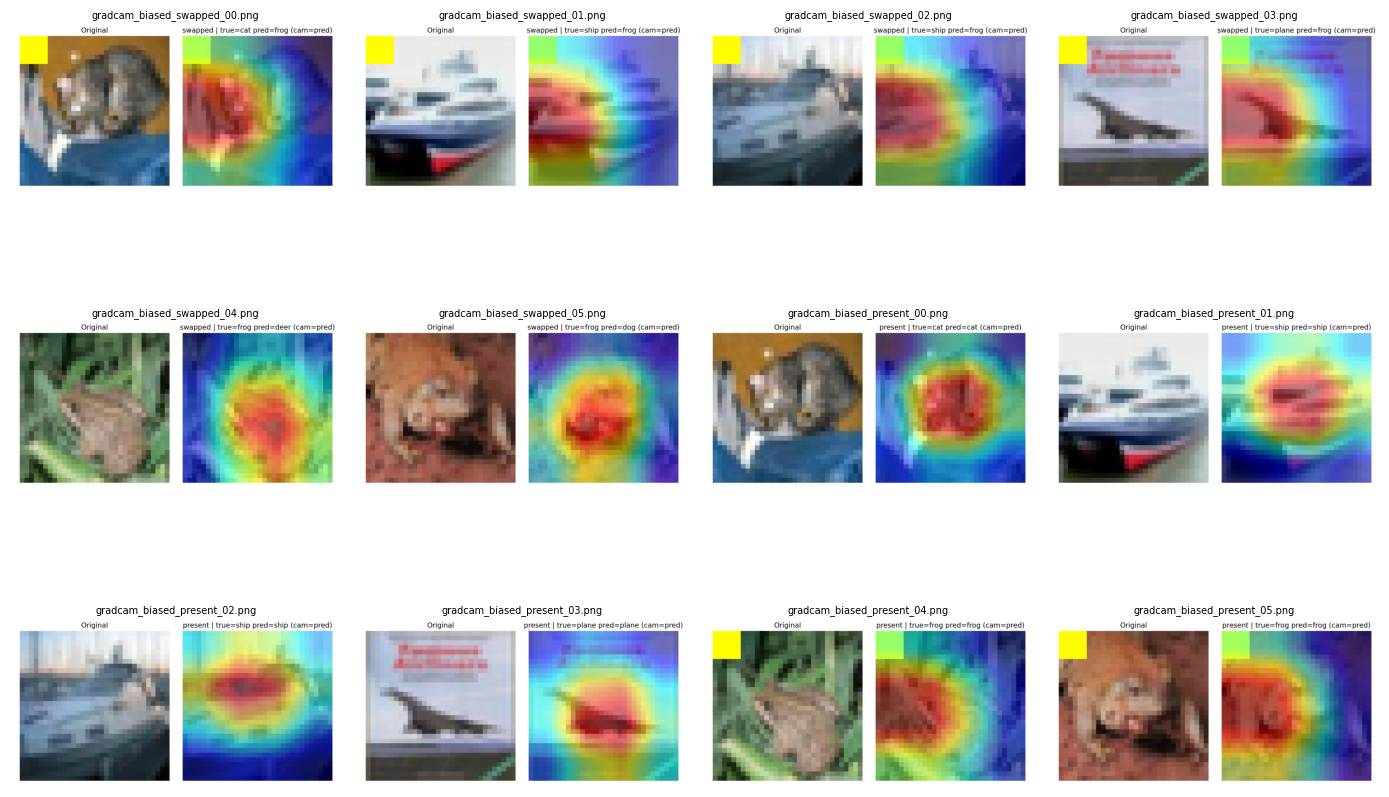

In [ ]:
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt

paths = sorted(glob("outputs_ms2/gradcam_biased_*swapped*.png"))[:6] + \
        sorted(glob("outputs_ms2/gradcam_biased_*present*.png"))[:6]

plt.figure(figsize=(14, 10))
for i, p in enumerate(paths):
    img = Image.open(p)
    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(p.split("/")[-1], fontsize=7)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
!zip -r outputs_ms2.zip outputs_ms2


  adding: outputs_ms2/ (stored 0%)
  adding: outputs_ms2/gradcam_biased_swapped_04.png (deflated 26%)
  adding: outputs_ms2/gradcam_baseline_removed_01.png (deflated 26%)
  adding: outputs_ms2/gradcam_baseline_present_04.png (deflated 27%)
  adding: outputs_ms2/gradcam_baseline_removed_05.png (deflated 26%)
  adding: outputs_ms2/gradcam_biased_present_02.png (deflated 27%)
  adding: outputs_ms2/gradcam_baseline_present_00.png (deflated 28%)
  adding: outputs_ms2/gradcam_baseline_swapped_00.png (deflated 27%)
  adding: outputs_ms2/gradcam_biased_present_01.png (deflated 27%)
  adding: outputs_ms2/gradcam_biased_removed_00.png (deflated 27%)
  adding: outputs_ms2/gradcam_biased_removed_04.png (deflated 26%)
  adding: outputs_ms2/gradcam_biased_present_04.png (deflated 27%)
  adding: outputs_ms2/gradcam_biased_removed_02.png (deflated 26%)
  adding: outputs_ms2/gradcam_biased_removed_03.png (deflated 27%)
  adding: outputs_ms2/gradcam_biased_swapped_00.png (deflated 26%)
  adding: outputs

In [ ]:
from google.colab import files
files.download("outputs_ms2.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>